In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

In [3]:
O_TRAIN  = r"C:\Users\abiga\OneDrive\Desktop\ML\O_Fe_training_data.csv"
O_TEST   = r"C:\Users\abiga\OneDrive\Desktop\ML\O_Fe_TEST_DATA.csv"

NA_TRAIN = r"C:\Users\abiga\OneDrive\Desktop\ML\Na_Fe_training_data.csv"
NA_TEST  = r"C:\Users\abiga\OneDrive\Desktop\ML\Na_Fe_TEST_DATA.csv"

train_o = pd.read_csv(O_TRAIN)
test_o = pd.read_csv(O_TEST)

train_na = pd.read_csv(NA_TRAIN)
test_na = pd.read_csv(NA_TEST)

In [4]:
train_o = train_o.copy()
test_o = test_o.copy()

train_o["FeH_used"] = train_o["Fe/H"].fillna(train_o["Fe/H_o"])
test_o["FeH_used"] = test_o["Fe/H"].fillna(test_o["Fe/H_o"])

# create colors
for df in [train_o, test_o]:
    df["c1"] = df["F275W"] - df["F336W"]
    df["c2"] = df["F336W"] - df["F438W"]
    df["c3"] = df["F438W"] - df["F606W"]
    df["c4"] = df["F606W"] - df["F814W"]

# use colors + age + chosen metallicity
feature_cols_o = ["c1", "c2", "c3", "c4", "age_Kruijssen", "FeH_used"]
target_col_o = "O/Fe"

# now drop missing values
train_o = train_o.dropna(subset=feature_cols_o + [target_col_o])
test_o = test_o.dropna(subset=feature_cols_o + [target_col_o])

In [5]:
train_na = train_na.copy()
test_na = test_na.copy()

train_na["FeH_used"] = train_na["Fe/H"].fillna(train_na["Fe/H_o"])
test_na["FeH_used"] = test_na["Fe/H"].fillna(test_na["Fe/H_o"])

for df in [train_na, test_na]:
    df["c1"] = df["F275W"] - df["F336W"]
    df["c2"] = df["F336W"] - df["F438W"]
    df["c3"] = df["F438W"] - df["F606W"]
    df["c4"] = df["F606W"] - df["F814W"]

feature_cols_na = ["c1", "c2", "c3", "c4", "age_Kruijssen", "FeH_used"]
target_col_na = "Na/Fe"

train_na = train_na.dropna(subset=feature_cols_na + [target_col_na])
test_na = test_na.dropna(subset=feature_cols_na + [target_col_na])

In [6]:
target_col_o = "O/Fe"

X_train_o = train_o[feature_cols_o]
y_train_o = train_o[target_col_o]

X_test_o = test_o[feature_cols_o]
y_test_o = test_o[target_col_o]


In [7]:
target_col_na = "Na/Fe"

X_train_na = train_na[feature_cols_na]
y_train_na = train_na[target_col_na]

X_test_na = test_na[feature_cols_na]
y_test_na = test_na[target_col_na]


In [57]:
degrees = [1, 2, 3]
alphas = [0.01, 0.1, 1, 10, 100, 1000]

best_rmse_o = float("inf")
best_config_o = None

for d in degrees:
    for a in alphas:
        model = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(-1, 1))),
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("ridge", Ridge(alpha=a))
        ])

        model.fit(X_train_o, y_train_o)
        y_pred_o = model.predict(X_test_o)

        rmse_o = np.sqrt(mean_squared_error(y_test_o, y_pred_o))

        if rmse_o < best_rmse_o:
            best_rmse_o = rmse_o
            best_config_o = (d, a)

print("Best RMSE:", best_rmse_o)
print("Best degree, alpha:", best_config_o)

Best RMSE: 0.21367763602416817
Best degree, alpha: (2, 1)


In [74]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

model_o = Pipeline([
    ("scaler", MinMaxScaler(feature_range=(-1, 1))),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("ridge", Ridge(alpha=1.0))
])

model_o.fit(X_train_o, y_train_o)
y_pred_o = model_o.predict(X_test_o)

rmse_o = np.sqrt(mean_squared_error(y_test_o, y_pred_o))
r2_o = r2_score(y_test_o, y_pred_o)

print("RMSE =", rmse_o)
print("R^2 =", r2_o)

RMSE = 0.21367763602416817
R^2 = 0.38444115472497853


In [59]:
degrees = [1, 2, 3]
alphas = [0.01, 0.1, 1, 10, 100, 1000]

best_rmse_na = float("inf")
best_config_na = None

for d in degrees:
    for a in alphas:
        model = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(-1, 1))),
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("ridge", Ridge(alpha=a))
        ])

        model.fit(X_train_na, y_train_na)
        y_pred_na = model.predict(X_test_na)

        rmse_na = np.sqrt(mean_squared_error(y_test_na, y_pred_na))

        if rmse_na < best_rmse_na:
            best_rmse_na = rmse_na
            best_config_na = (d, a)

print("Best RMSE:", best_rmse_na)
print("Best degree, alpha:", best_config_na)

Best RMSE: 0.22900909884734144
Best degree, alpha: (2, 1)


In [1]:
model_na = Pipeline([
    ("scaler", MinMaxScaler(feature_range=(-1, 1))),
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("ridge", Ridge(alpha=1.0))
])

model_na.fit(X_train_na, y_train_na)
y_pred_na = model_na.predict(X_test_na)

rmse_na = np.sqrt(mean_squared_error(y_test_na, y_pred_na))
r2_na = r2_score(y_test_na, y_pred_na)

print("R^2 =", r2_na)
print("RMSE =", rmse_na)

NameError: name 'Pipeline' is not defined

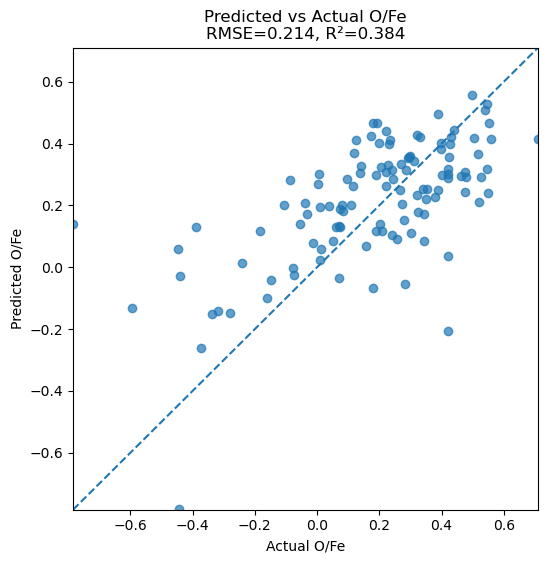

In [76]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_o, y_pred_o, alpha=0.7)

min_val = min(y_test_o.min(), y_pred_o.min())
max_val = max(y_test_o.max(), y_pred_o.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual O/Fe")
plt.ylabel("Predicted O/Fe")
plt.title(f"Predicted vs Actual O/Fe\nRMSE={rmse_o:.3f}, R²={r2_o:.3f}")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.show()

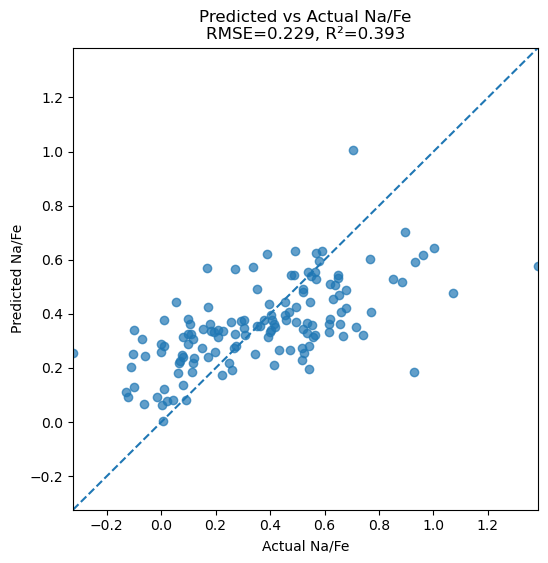

In [77]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_na, y_pred_na, alpha=0.7)

min_val = min(y_test_na.min(), y_pred_na.min())
max_val = max(y_test_na.max(), y_pred_na.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Na/Fe")
plt.ylabel("Predicted Na/Fe")
plt.title(f"Predicted vs Actual Na/Fe\nRMSE={rmse_na:.3f}, R²={r2_na:.3f}")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.show()

In [78]:
poly_o = model_o.named_steps["poly"]
ridge_o = model_o.named_steps["ridge"]

feature_names_o = poly_o.get_feature_names_out(feature_cols_o)

print("Intercept:", ridge_o.intercept_)
for name, coef in zip(feature_names_o, ridge_o.coef_):
    print(name, coef)

Intercept: 0.09645367306668935
c1 0.7278111665007136
c2 -0.7104867321830391
c3 -0.15861926495451173
c4 0.3281836988216732
age_Kruijssen 0.08246017866817812
FeH_used -0.3872567001113793
c1^2 0.3474684343703849
c1 c2 0.13836372033551358
c1 c3 -0.2560885951517217
c1 c4 -0.4473756763353751
c1 age_Kruijssen -0.09142733433038616
c1 FeH_used -0.1457912913350711
c2^2 0.16987408334483178
c2 c3 0.3432552581203395
c2 c4 0.1821520075507847
c2 age_Kruijssen -0.22044203676516663
c2 FeH_used 0.006479918792756989
c3^2 0.20478725351658017
c3 c4 0.12346660481691486
c3 age_Kruijssen -0.02503370644042596
c3 FeH_used -0.2789571765385571
c4^2 -0.11238946596641843
c4 age_Kruijssen 0.08830007586852615
c4 FeH_used 0.05163878768713144
age_Kruijssen^2 0.008313273919277645
age_Kruijssen FeH_used 0.24691780527342033
FeH_used^2 -0.19670118231730369


In [79]:
poly_na = model_na.named_steps["poly"]
ridge_na = model_na.named_steps["ridge"]

feature_names_na = poly_na.get_feature_names_out(feature_cols_na)

print("Intercept:", ridge_na.intercept_)
for name, coef in zip(feature_names_na, ridge_na.coef_):
    print(name, coef)

Intercept: 0.6164585483322725
c1 -0.7467659952637826
c2 0.7755268845226561
c3 0.12191595958009166
c4 -0.29122168582797153
age_Kruijssen 0.1971644215309679
FeH_used 0.06065615316581788
c1^2 0.0071095431970819665
c1 c2 0.14735819140014644
c1 c3 0.2498293429092522
c1 c4 0.07647505573115648
c1 age_Kruijssen -0.014787096563128831
c1 FeH_used 0.06003464608189463
c2^2 -0.5667982393889809
c2 c3 -0.4415803910886962
c2 c4 -0.23282995557168507
c2 age_Kruijssen -0.1066963357481558
c2 FeH_used 0.23758501650175462
c3^2 -0.10907484365288006
c3 c4 0.07676476010934956
c3 age_Kruijssen 0.22034512748704713
c3 FeH_used -0.13697979592930107
c4^2 0.19017733669563705
c4 age_Kruijssen 0.18707282980804793
c4 FeH_used -0.2072099989058198
age_Kruijssen^2 -0.09383462757419207
age_Kruijssen FeH_used -0.10716607013309803
FeH_used^2 0.17364763417362755
